In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'

os.makedirs('images', exist_ok=True)
os.makedirs('data',   exist_ok=True)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
apps    = pd.read_csv('data/apps.csv')
reviews = pd.read_csv('data/user_reviews.csv')

print("Datasets Loaded")
print(f"\nApps Dataset     : {apps.shape[0]:,} rows × {apps.shape[1]} columns")
print(f"Reviews Dataset  : {reviews.shape[0]:,} rows × {reviews.shape[1]} columns")
print(f"\nApps Columns     : {apps.columns.tolist()}")
print(f"Reviews Columns  : {reviews.columns.tolist()}")

Datasets Loaded

Apps Dataset     : 9,659 rows × 14 columns
Reviews Dataset  : 64,295 rows × 5 columns

Apps Columns     : ['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
Reviews Columns  : ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [3]:
print("=" * 55)
print("     APPS DATASET — INFO")
print("=" * 55)
apps.info()

print("\n" + "=" * 55)
print("     REVIEWS DATASET — INFO")
print("=" * 55)
reviews.info()

     APPS DATASET — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB

     REVIEWS DATASET — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 

In [5]:
print("=" * 55)
print("     DATA CLEANING — APPS DATASET")
print("=" * 55)

# Drop unnamed index column
apps.drop(columns=['Unnamed: 0'], inplace=True)

# Drop duplicates
before = len(apps)
apps.drop_duplicates(inplace=True)
apps.drop_duplicates(subset='App', keep='first', inplace=True)
print(f"Duplicates removed : {before - len(apps)}")

# Drop rows where Type is NaN or '0'
apps = apps[apps['Type'].isin(['Free', 'Paid'])]

# Clean Price — remove $ sign and convert to float
apps['Price'] = apps['Price'].str.replace('$', '', regex=False).astype(float)

# Clean Installs — remove commas and + sign
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)\
                                   .str.replace('+', '', regex=False)\
                                   .astype(int)

# Convert Last Updated to datetime
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'])

# Fill missing Rating with median
rating_median = apps['Rating'].median()
apps['Rating'].fillna(rating_median, inplace=True)

# Fill missing Size with median
apps['Size'].fillna(apps['Size'].median(), inplace=True)

# Clean Category names — replace underscores
apps['Category Clean'] = apps['Category'].str.replace('_', ' ').str.title()

print(f"Missing Values after cleaning:\n{apps.isnull().sum()}")
print(f"\nFinal Shape        : {apps.shape}")
print(f"Rating filled with : {rating_median}")
print("\nApps Dataset Cleaned")
apps.head()

     DATA CLEANING — APPS DATASET
Duplicates removed : 0
Missing Values after cleaning:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       2
Category Clean    0
dtype: int64

Final Shape        : (9659, 14)
Rating filled with : 4.3

Apps Dataset Cleaned


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Category Clean
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Art And Design
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,Art And Design
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,Art And Design
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,Art And Design
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,Art And Design


In [6]:
print("=" * 55)
print("     DATA CLEANING — REVIEWS DATASET")
print("=" * 55)

# Drop rows with null sentiment
reviews.dropna(subset=['Sentiment', 'Sentiment_Polarity',
                        'Sentiment_Subjectivity'], inplace=True)

# Drop null reviews text
reviews.dropna(subset=['Translated_Review'], inplace=True)

print(f"Missing after cleaning:\n{reviews.isnull().sum()}")
print(f"\nFinal Shape : {reviews.shape}")
print(f"Sentiments  : {reviews['Sentiment'].unique().tolist()}")
print(f"\nSentiment Distribution:")
print(reviews['Sentiment'].value_counts())
print("\nReviews Dataset Cleaned")
reviews.head()

     DATA CLEANING — REVIEWS DATASET
Missing after cleaning:
App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

Final Shape : (37427, 5)
Sentiments  : ['Positive', 'Neutral', 'Negative']

Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64

Reviews Dataset Cleaned


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


In [7]:
print("=" * 55)
print("     KEY MARKET METRICS")
print("=" * 55)
print(f"  Total Apps          : {len(apps):,}")
print(f"  Total Categories    : {apps['Category'].nunique()}")
print(f"  Free Apps           : {(apps['Type']=='Free').sum():,} "
      f"({(apps['Type']=='Free').mean()*100:.1f}%)")
print(f"  Paid Apps           : {(apps['Type']=='Paid').sum():,} "
      f"({(apps['Type']=='Paid').mean()*100:.1f}%)")
print(f"  Avg Rating          : {apps['Rating'].mean():.2f} / 5.0")
print(f"  Avg Price (Paid)    : ${apps[apps['Type']=='Paid']['Price'].mean():.2f}")
print(f"  Max Installs        : {apps['Installs'].max():,}")
print(f"  Total Reviews       : {reviews.shape[0]:,}")
print(f"  Content Ratings     : {apps['Content Rating'].nunique()}")
print()
print(apps[['Rating','Reviews','Size','Installs','Price']].describe().round(2))

     KEY MARKET METRICS
  Total Apps          : 9,659
  Total Categories    : 33
  Free Apps           : 8,903 (92.2%)
  Paid Apps           : 756 (7.8%)
  Avg Rating          : 4.19 / 5.0
  Avg Price (Paid)    : $14.05
  Max Installs        : 1,000,000,000
  Total Reviews       : 37,427
  Content Ratings     : 6

        Rating      Reviews     Size      Installs    Price
count  9659.00      9659.00  9659.00  9.659000e+03  9659.00
mean      4.19    216592.56    19.33  7.777507e+06     1.10
std       0.50   1831319.57    20.58  5.375828e+07    16.85
min       1.00         0.00     0.00  0.000000e+00     0.00
25%       4.00        25.00     5.30  1.000000e+03     0.00
50%       4.30       967.00    12.00  1.000000e+05     0.00
75%       4.50     29401.00    25.00  1.000000e+06     0.00
max       5.00  78158306.00   100.00  1.000000e+09   400.00


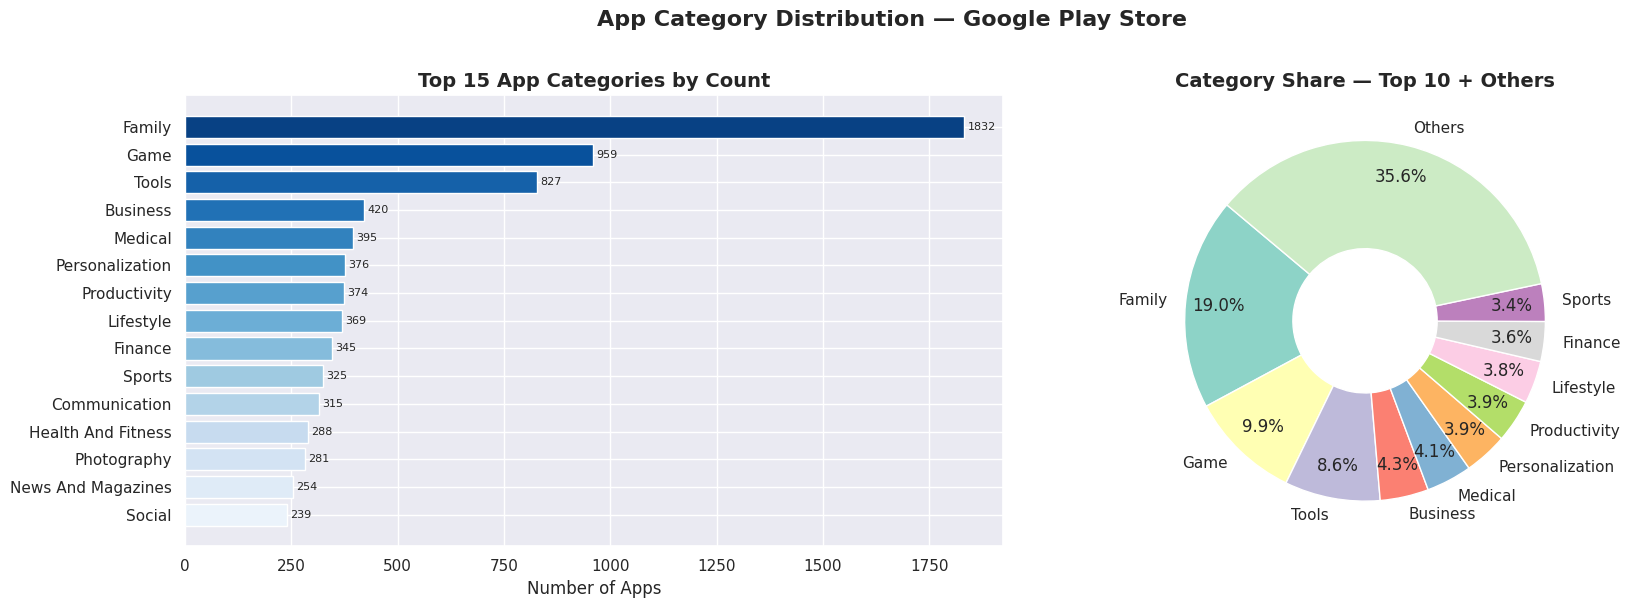

In [8]:
cat_counts = apps['Category Clean'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 15 categories bar
colors_bar = sns.color_palette('Blues_r', len(cat_counts))
bars = axes[0].barh(cat_counts.index[::-1],
                    cat_counts.values[::-1],
                    color=colors_bar[::-1], edgecolor='white')
axes[0].set_title('Top 15 App Categories by Count',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Apps')
for bar in bars:
    axes[0].text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())),
                 va='center', fontsize=8)

# Top 10 pie
top10 = apps['Category Clean'].value_counts().head(10)
others = len(apps) - top10.sum()
pie_data   = list(top10.values) + [others]
pie_labels = list(top10.index) + ['Others']
axes[1].pie(pie_data, labels=pie_labels,
            autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(pie_data)),
            startangle=140, pctdistance=0.82,
            wedgeprops=dict(width=0.6))
axes[1].set_title('Category Share — Top 10 + Others',
                   fontsize=14, fontweight='bold')

plt.suptitle('App Category Distribution — Google Play Store',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

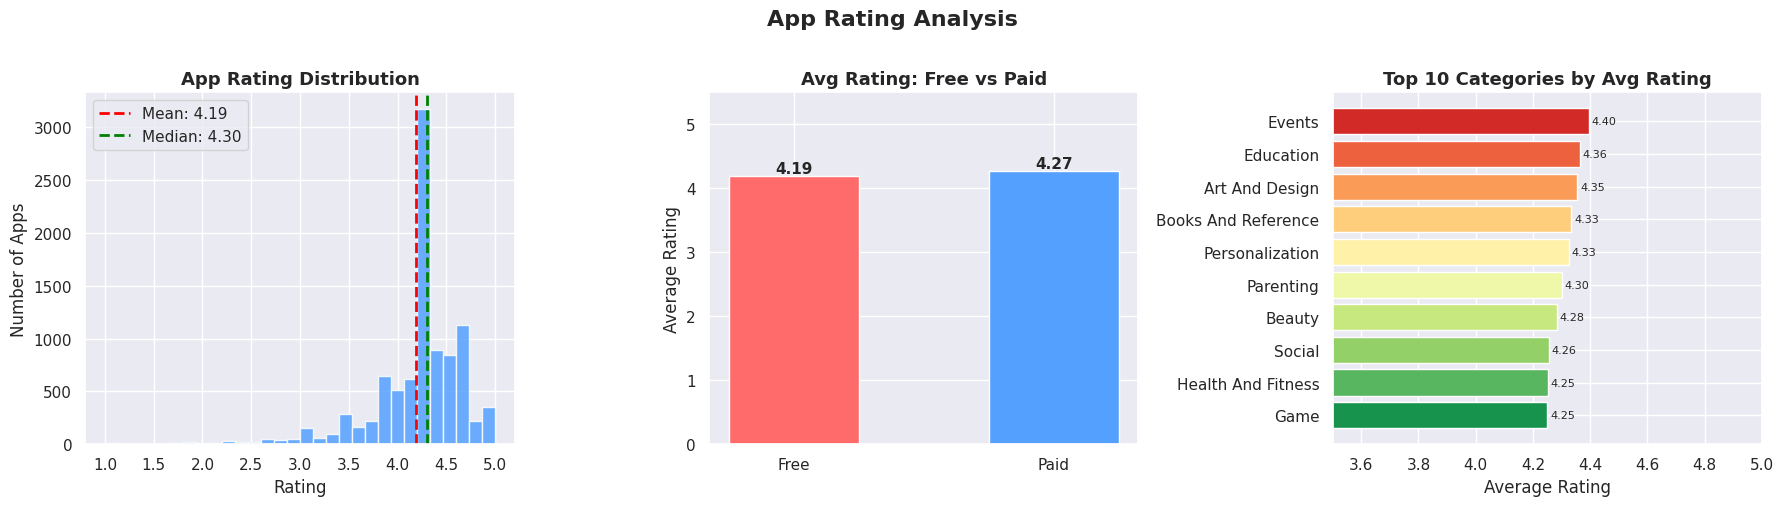

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating distribution
axes[0].hist(apps['Rating'], bins=30, color='#54A0FF',
             edgecolor='white', alpha=0.85)
axes[0].axvline(apps['Rating'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {apps['Rating'].mean():.2f}")
axes[0].axvline(apps['Rating'].median(), color='green', linestyle='--',
                linewidth=2, label=f"Median: {apps['Rating'].median():.2f}")
axes[0].set_title('App Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Apps')
axes[0].legend()

# Avg rating by type
type_rating = apps.groupby('Type')['Rating'].mean()
colors_t = ['#FF6B6B', '#54A0FF']
bars = axes[1].bar(type_rating.index, type_rating.values,
                   color=colors_t, edgecolor='white', width=0.5)
axes[1].set_title('Avg Rating: Free vs Paid', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 5.5)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{bar.get_height():.2f}',
                 ha='center', fontsize=11, fontweight='bold')

# Top 10 highest rated categories
cat_rating = apps.groupby('Category Clean')['Rating'].mean()\
                 .sort_values(ascending=False).head(10)
axes[2].barh(cat_rating.index[::-1], cat_rating.values[::-1],
             color=sns.color_palette('RdYlGn', 10)[::-1],
             edgecolor='white')
axes[2].set_title('Top 10 Categories by Avg Rating',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Average Rating')
axes[2].set_xlim(3.5, 5.0)
for i, v in enumerate(cat_rating.values[::-1]):
    axes[2].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)

plt.suptitle('App Rating Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/rating_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

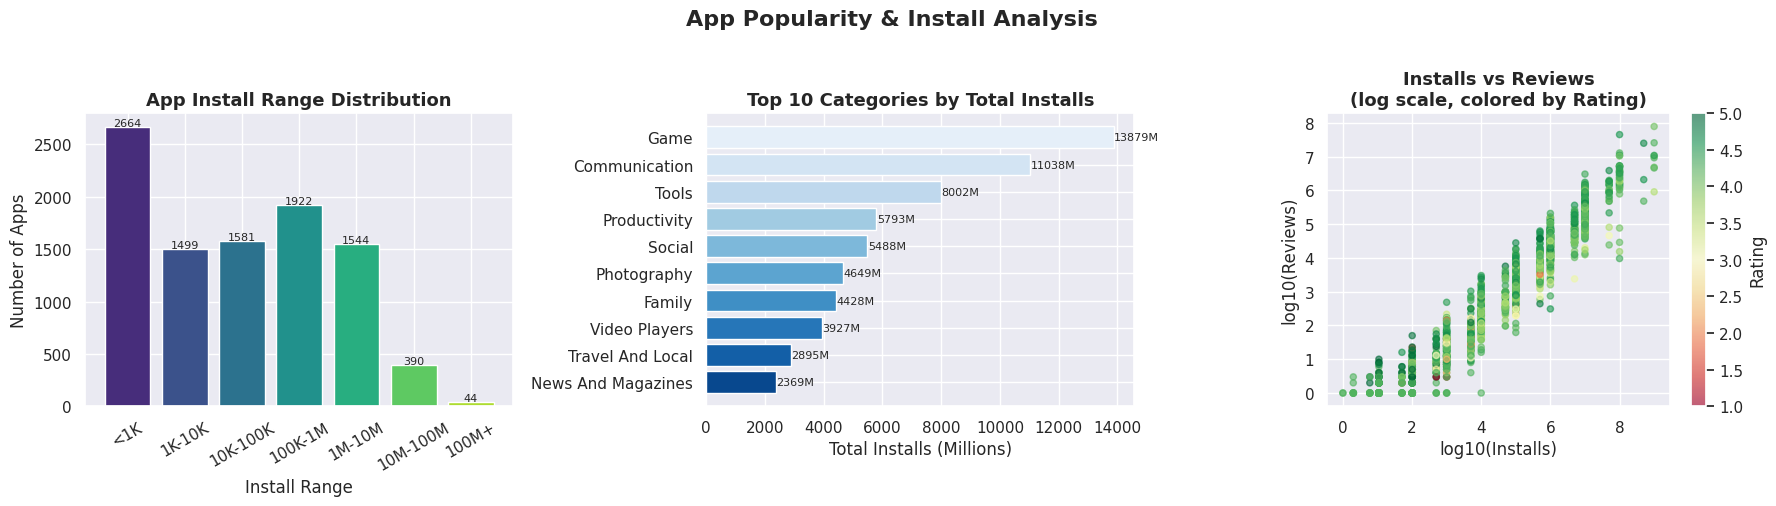

In [10]:
# Installs buckets
bins   = [0, 1000, 10000, 100000, 1000000, 10000000, 100000000, float('inf')]
labels = ['<1K','1K-10K','10K-100K','100K-1M','1M-10M','10M-100M','100M+']
apps['Install Range'] = pd.cut(apps['Installs'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Install range distribution
install_counts = apps['Install Range'].value_counts().reindex(labels)
colors_i = sns.color_palette('viridis', len(labels))
axes[0].bar(install_counts.index, install_counts.values,
            color=colors_i, edgecolor='white')
axes[0].set_title('App Install Range Distribution',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Install Range')
axes[0].set_ylabel('Number of Apps')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(install_counts.values):
    if pd.notna(v) and v > 0:
        axes[0].text(i, v + 10, str(int(v)),
                     ha='center', fontsize=8)

# Top 10 most installed categories
cat_installs = apps.groupby('Category Clean')['Installs'].sum()\
                   .sort_values(ascending=False).head(10)
axes[1].barh(cat_installs.index[::-1],
             cat_installs.values[::-1] / 1e6,
             color=sns.color_palette('Blues_r', 10),
             edgecolor='white')
axes[1].set_title('Top 10 Categories by Total Installs',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Installs (Millions)')
for i, v in enumerate(cat_installs.values[::-1] / 1e6):
    axes[1].text(v + 10, i, f'{v:.0f}M', va='center', fontsize=8)

# Reviews vs Installs scatter
sample = apps.sample(min(1500, len(apps)), random_state=42)
scatter = axes[2].scatter(
    np.log10(sample['Installs'] + 1),
    np.log10(sample['Reviews'] + 1),
    c=sample['Rating'],
    cmap='RdYlGn', alpha=0.6, s=20,
    vmin=1, vmax=5
)
plt.colorbar(scatter, ax=axes[2], label='Rating')
axes[2].set_title('Installs vs Reviews\n(log scale, colored by Rating)',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('log10(Installs)')
axes[2].set_ylabel('log10(Reviews)')

plt.suptitle('App Popularity & Install Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/installs_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

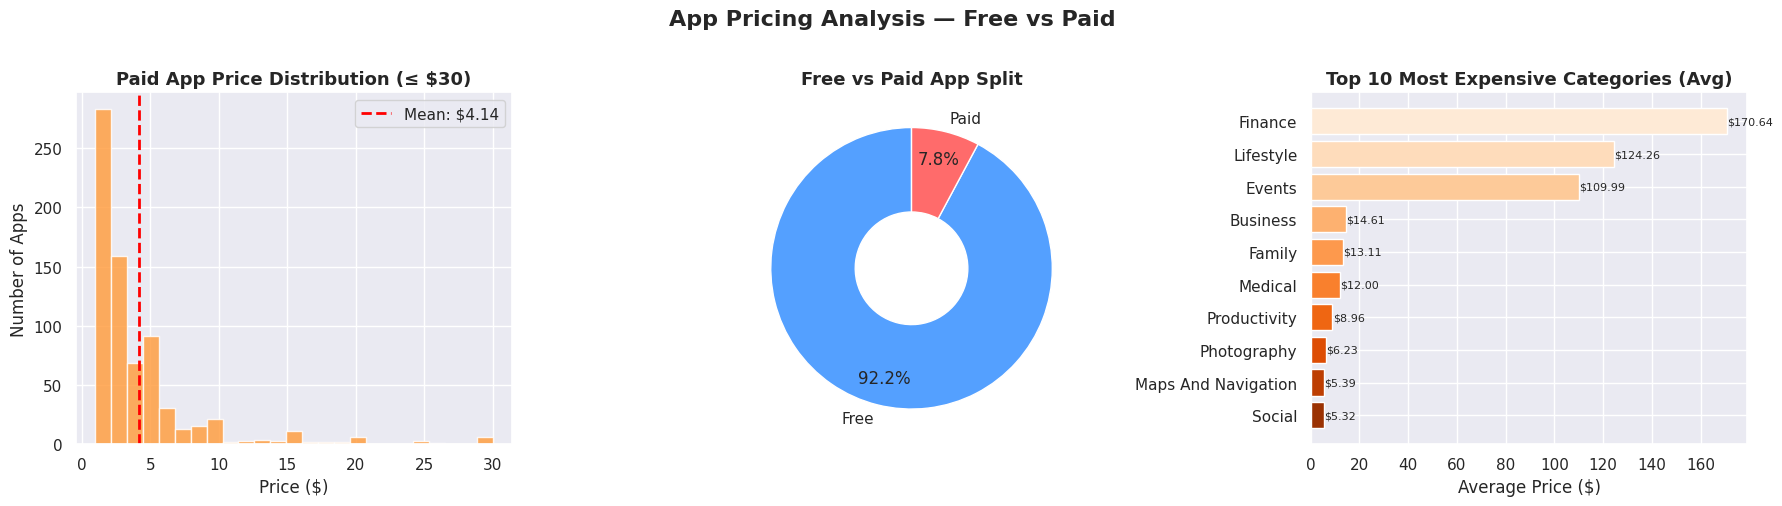

In [11]:
paid_apps = apps[apps['Type'] == 'Paid'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price distribution (capped at $30)
paid_capped = paid_apps[paid_apps['Price'] <= 30]
axes[0].hist(paid_capped['Price'], bins=25, color='#FF9F43',
             edgecolor='white', alpha=0.85)
axes[0].axvline(paid_capped['Price'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f"Mean: ${paid_capped['Price'].mean():.2f}")
axes[0].set_title('Paid App Price Distribution (≤ $30)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Number of Apps')
axes[0].legend()

# Free vs Paid count
type_counts = apps['Type'].value_counts()
axes[1].pie(type_counts, labels=type_counts.index,
            autopct='%1.1f%%',
            colors=['#54A0FF', '#FF6B6B'],
            startangle=90,
            wedgeprops=dict(width=0.6),
            pctdistance=0.8)
axes[1].set_title('Free vs Paid App Split',
                   fontsize=13, fontweight='bold')

# Top 10 most expensive categories
cat_price = paid_apps.groupby('Category Clean')['Price'].mean()\
                     .sort_values(ascending=False).head(10)
axes[2].barh(cat_price.index[::-1], cat_price.values[::-1],
             color=sns.color_palette('Oranges_r', 10),
             edgecolor='white')
axes[2].set_title('Top 10 Most Expensive Categories (Avg)',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Average Price ($)')
for i, v in enumerate(cat_price.values[::-1]):
    axes[2].text(v + 0.1, i, f'${v:.2f}', va='center', fontsize=8)

plt.suptitle('App Pricing Analysis — Free vs Paid',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/pricing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

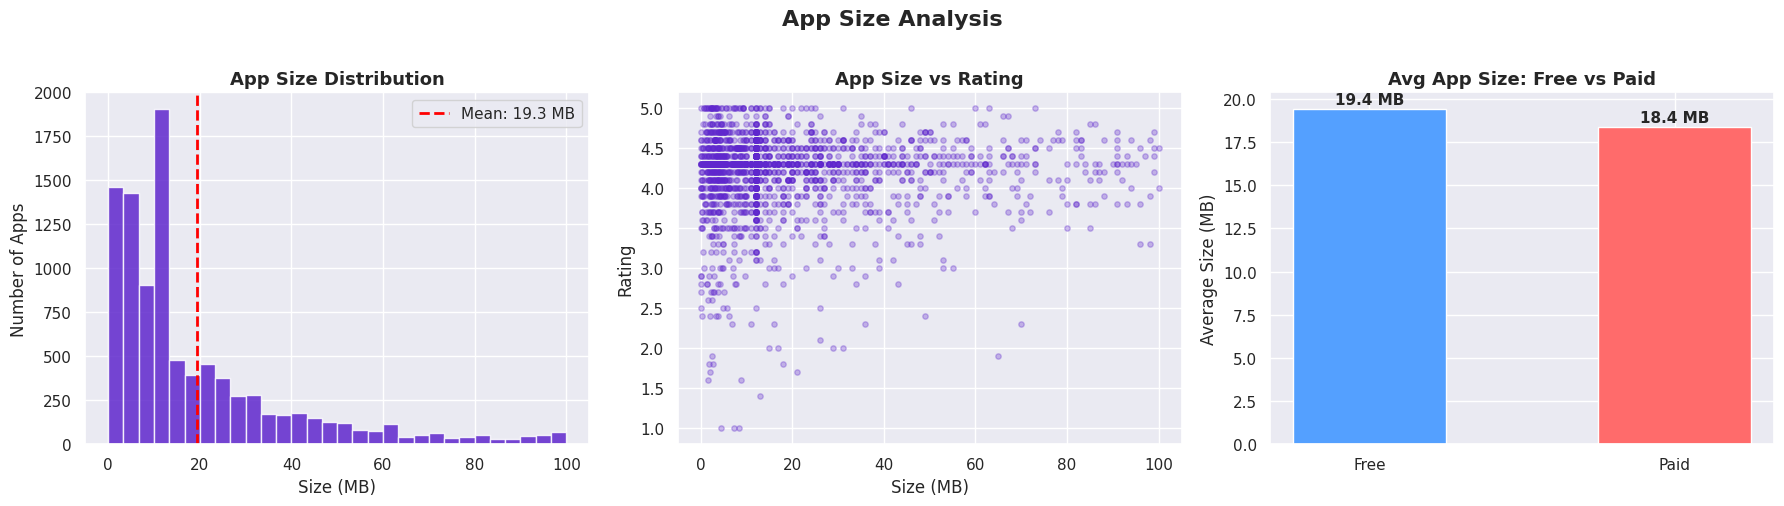

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Size distribution
axes[0].hist(apps['Size'].dropna(), bins=30,
             color='#5F27CD', edgecolor='white', alpha=0.85)
axes[0].axvline(apps['Size'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {apps['Size'].mean():.1f} MB")
axes[0].set_title('App Size Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Size (MB)')
axes[0].set_ylabel('Number of Apps')
axes[0].legend()

# Size vs Rating scatter
sample2 = apps.dropna(subset=['Size','Rating']).sample(
    min(2000, len(apps)), random_state=42)
axes[1].scatter(sample2['Size'], sample2['Rating'],
                alpha=0.3, color='#5F27CD', s=15)
axes[1].set_title('App Size vs Rating',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Size (MB)')
axes[1].set_ylabel('Rating')

# Avg size by type
size_type = apps.groupby('Type')['Size'].mean()
axes[2].bar(size_type.index, size_type.values,
            color=['#54A0FF','#FF6B6B'], edgecolor='white', width=0.5)
axes[2].set_title('Avg App Size: Free vs Paid',
                   fontsize=13, fontweight='bold')
axes[2].set_ylabel('Average Size (MB)')
for i, v in enumerate(size_type.values):
    axes[2].text(i, v + 0.3, f'{v:.1f} MB',
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle('App Size Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/size_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

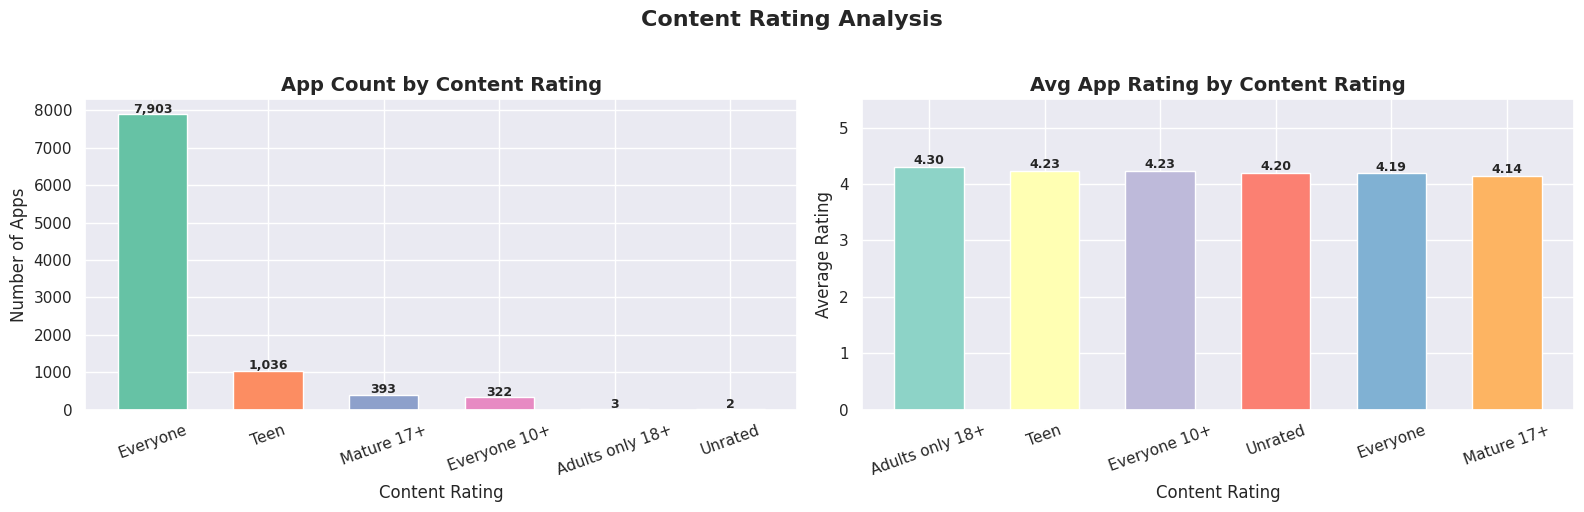

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count by content rating
cr_counts = apps['Content Rating'].value_counts()
bar_colors = sns.color_palette('Set2', len(cr_counts))

# Bar 1 — App count by content rating
bars = axes[0].bar(
    cr_counts.index,
    cr_counts.values,
    color=bar_colors,
    edgecolor='white',
    width=0.6
)
axes[0].set_title('App Count by Content Rating',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Apps')
axes[0].set_xlabel('Content Rating')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 40,
        f'{int(bar.get_height()):,}',
        ha='center', fontsize=9, fontweight='bold'
    )

# Bar 2 — Avg rating by content rating
cr_rating = apps.groupby('Content Rating')['Rating'].mean()\
                .sort_values(ascending=False)
bar_colors2 = sns.color_palette('Set3', len(cr_rating))
bars2 = axes[1].bar(
    cr_rating.index,
    cr_rating.values,
    color=bar_colors2,
    edgecolor='white',
    width=0.6
)
axes[1].set_title('Avg App Rating by Content Rating',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_xlabel('Content Rating')
axes[1].set_ylim(0, 5.5)
axes[1].tick_params(axis='x', rotation=20)
for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.2f}',
        ha='center', fontsize=9, fontweight='bold'
    )

plt.suptitle('Content Rating Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/content_rating_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

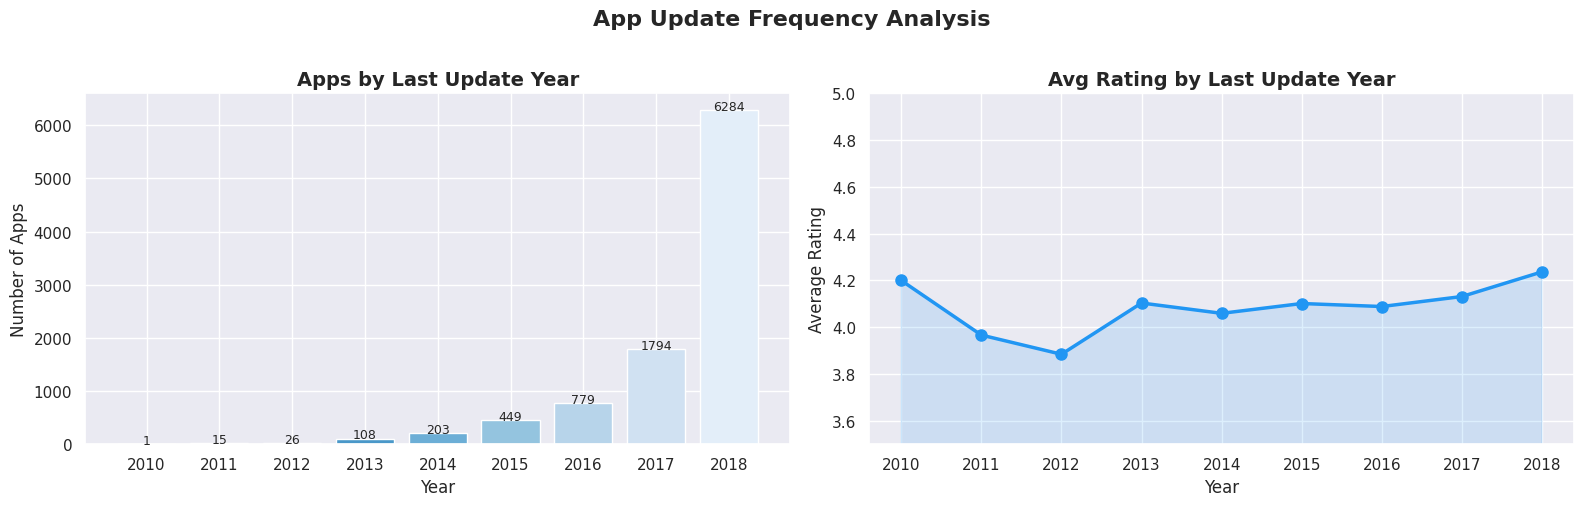

In [15]:
apps['Update Year']  = apps['Last Updated'].dt.year
apps['Update Month'] = apps['Last Updated'].dt.strftime('%B')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Updates by year
year_counts = apps['Update Year'].value_counts().sort_index()
axes[0].bar(year_counts.index.astype(str), year_counts.values,
            color=sns.color_palette('Blues_r', len(year_counts)),
            edgecolor='white')
axes[0].set_title('Apps by Last Update Year',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Apps')
for i, v in enumerate(year_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Avg rating by update year
rating_year = apps.groupby('Update Year')['Rating'].mean()
axes[1].plot(rating_year.index, rating_year.values,
             marker='o', color='#2196F3', linewidth=2.5, markersize=8)
axes[1].fill_between(rating_year.index, rating_year.values,
                     alpha=0.15, color='#2196F3')
axes[1].set_title('Avg Rating by Last Update Year',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.5, 5.0)

plt.suptitle('App Update Frequency Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/update_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("=" * 55)
print("     SENTIMENT ANALYSIS — USER REVIEWS")
print("=" * 55)

sentiment_counts = reviews['Sentiment'].value_counts()
print(f"\nSentiment Distribution:")
print(sentiment_counts)
print(f"\nPositive %  : {sentiment_counts['Positive']/len(reviews)*100:.1f}%")
print(f"Negative %  : {sentiment_counts['Negative']/len(reviews)*100:.1f}%")
print(f"Neutral  %  : {sentiment_counts['Neutral']/len(reviews)*100:.1f}%")
print(f"\nAvg Polarity    : {reviews['Sentiment_Polarity'].mean():.3f}")
print(f"Avg Subjectivity: {reviews['Sentiment_Subjectivity'].mean():.3f}")

     SENTIMENT ANALYSIS — USER REVIEWS

Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64

Positive %  : 64.1%
Negative %  : 22.1%
Neutral  %  : 13.8%

Avg Polarity    : 0.182
Avg Subjectivity: 0.493


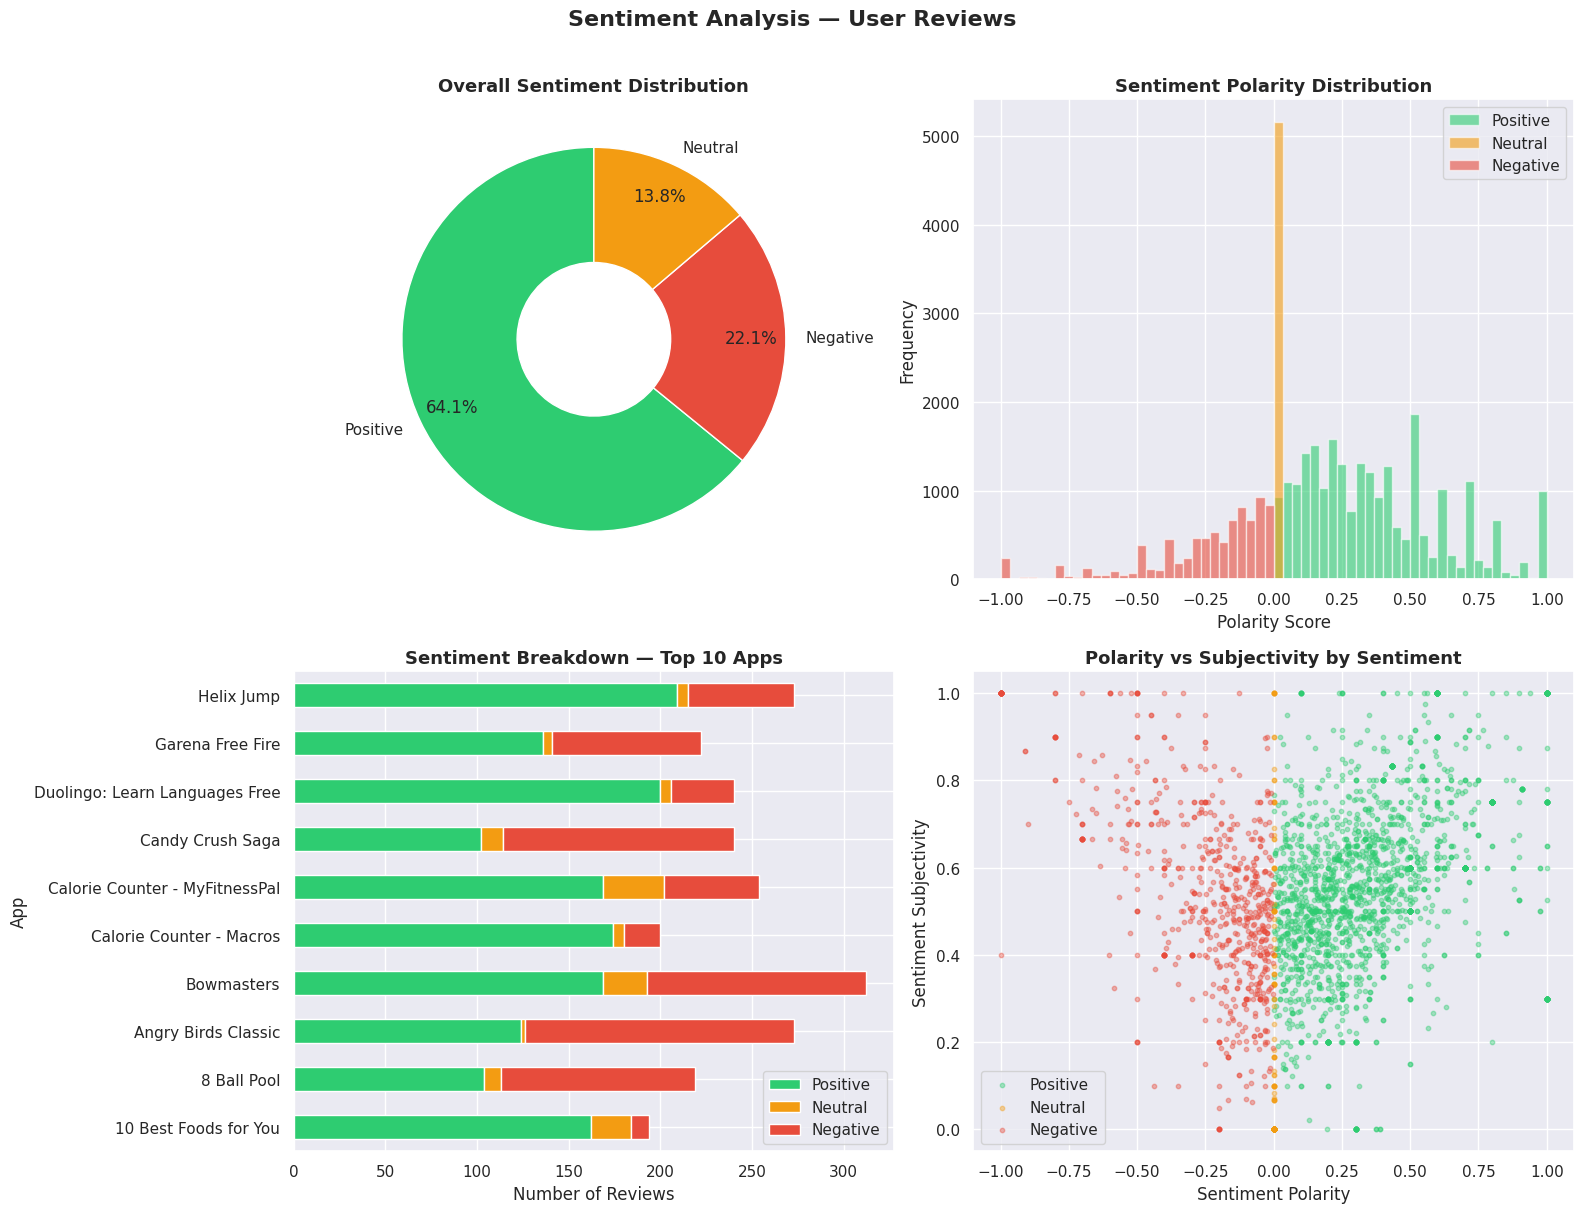

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sent_colors = {'Positive':'#2ecc71', 'Neutral':'#f39c12', 'Negative':'#e74c3c'}

# Sentiment distribution pie
colors_s = [sent_colors[s] for s in sentiment_counts.index]
axes[0,0].pie(sentiment_counts, labels=sentiment_counts.index,
              autopct='%1.1f%%', colors=colors_s,
              startangle=90, pctdistance=0.82,
              wedgeprops=dict(width=0.6))
axes[0,0].set_title('Overall Sentiment Distribution',
                     fontsize=13, fontweight='bold')

# Polarity distribution by sentiment
for sentiment, color in sent_colors.items():
    data = reviews[reviews['Sentiment'] == sentiment]['Sentiment_Polarity']
    axes[0,1].hist(data, bins=30, alpha=0.6,
                   color=color, label=sentiment, edgecolor='white')
axes[0,1].set_title('Sentiment Polarity Distribution',
                     fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Polarity Score')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Sentiment per top 10 apps
top_apps = reviews['App'].value_counts().head(10).index
top_sentiment = reviews[reviews['App'].isin(top_apps)]\
    .groupby(['App','Sentiment']).size().unstack(fill_value=0)
top_sentiment[['Positive','Neutral','Negative']].plot(
    kind='barh', ax=axes[1,0], stacked=True,
    color=['#2ecc71','#f39c12','#e74c3c'],
    edgecolor='white')
axes[1,0].set_title('Sentiment Breakdown — Top 10 Apps',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Number of Reviews')
axes[1,0].legend(loc='lower right')

# Polarity vs Subjectivity scatter
sample_r = reviews.dropna().sample(min(3000, len(reviews)), random_state=42)
color_map = {'Positive':'#2ecc71','Neutral':'#f39c12','Negative':'#e74c3c'}
for sent in ['Positive','Neutral','Negative']:
    d = sample_r[sample_r['Sentiment']==sent]
    axes[1,1].scatter(d['Sentiment_Polarity'],
                      d['Sentiment_Subjectivity'],
                      alpha=0.4, s=10, color=color_map[sent], label=sent)
axes[1,1].set_title('Polarity vs Subjectivity by Sentiment',
                     fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Sentiment Polarity')
axes[1,1].set_ylabel('Sentiment Subjectivity')
axes[1,1].legend()

plt.suptitle('Sentiment Analysis — User Reviews',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

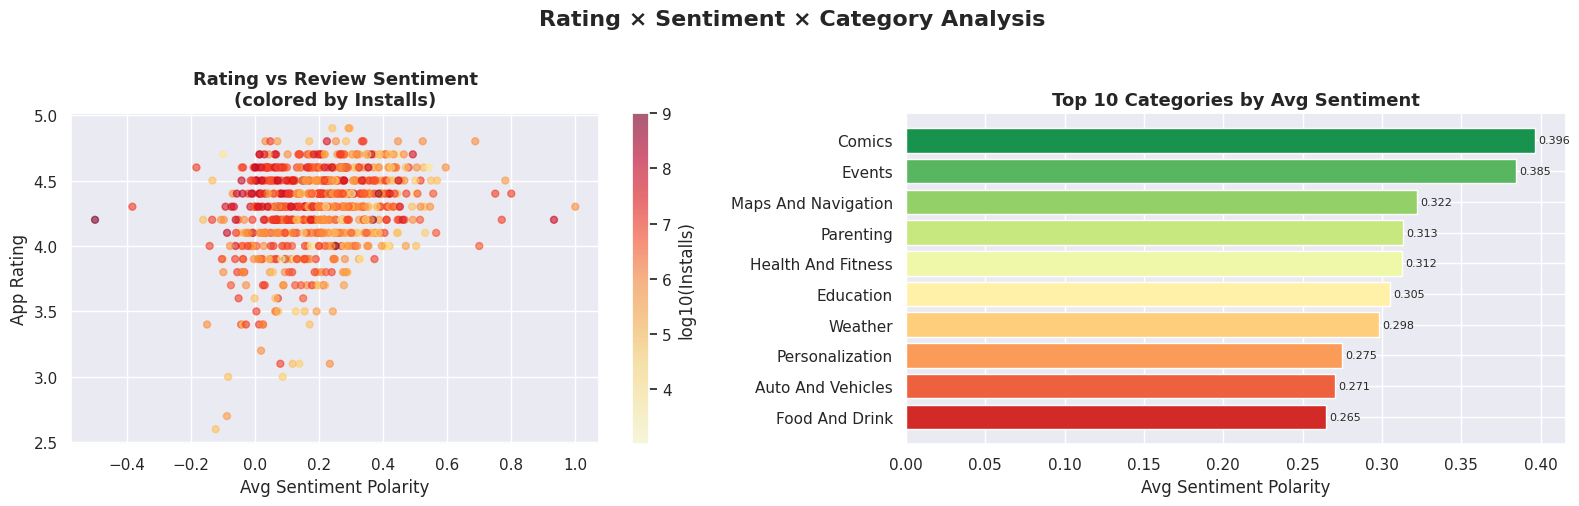

In [18]:
# Merge apps with sentiment
app_sentiment = reviews.groupby('App').agg(
    Avg_Polarity     = ('Sentiment_Polarity',    'mean'),
    Avg_Subjectivity = ('Sentiment_Subjectivity','mean'),
    Review_Count     = ('Translated_Review',     'count')
).reset_index()

merged = apps.merge(app_sentiment, on='App', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

merged_clean = merged.dropna(subset=['Avg_Polarity', 'Rating', 'Installs'])
sample_size  = min(800, len(merged_clean))   # was 2000 — caused error
sample_m     = merged_clean.sample(sample_size, random_state=42)

# Rating vs Avg Polarity scatter
scatter = axes[0].scatter(
    sample_m['Avg_Polarity'],
    sample_m['Rating'],
    c=np.log10(sample_m['Installs'] + 1),  
    cmap='YlOrRd',
    alpha=0.6,
    s=25
)
plt.colorbar(scatter, ax=axes[0], label='log10(Installs)')
axes[0].set_title('Rating vs Review Sentiment\n(colored by Installs)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg Sentiment Polarity')
axes[0].set_ylabel('App Rating')

# Avg polarity by category top 10
cat_pol = merged.groupby('Category Clean')['Avg_Polarity'].mean()\
               .sort_values(ascending=False).dropna().head(10)
colors_pol = sns.color_palette('RdYlGn', 10)
axes[1].barh(
    cat_pol.index[::-1],
    cat_pol.values[::-1],
    color=colors_pol,
    edgecolor='white'
)
axes[1].set_title('Top 10 Categories by Avg Sentiment',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Sentiment Polarity')
for i, v in enumerate(cat_pol.values[::-1]):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Rating × Sentiment × Category Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/merged_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

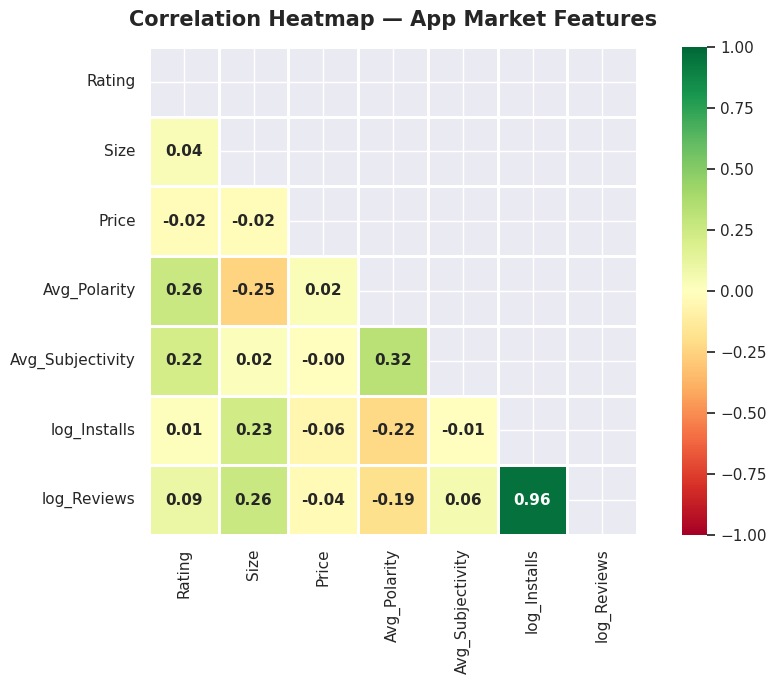

In [19]:
numeric_cols = merged[['Rating','Reviews','Size','Installs',
                        'Price','Avg_Polarity','Avg_Subjectivity']].copy()
numeric_cols['log_Installs'] = np.log10(numeric_cols['Installs'] + 1)
numeric_cols['log_Reviews']  = np.log10(numeric_cols['Reviews']  + 1)
numeric_cols.drop(columns=['Installs','Reviews'], inplace=True)

corr = numeric_cols.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.8, square=True, mask=mask,
            annot_kws={'size':11, 'weight':'bold'},
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap — App Market Features',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
top_cat_installs = apps.groupby('Category Clean')['Installs'].sum().idxmax()
top_cat_count    = apps['Category Clean'].value_counts().idxmax()
top_cat_rating   = apps.groupby('Category Clean')['Rating'].mean().idxmax()
paid_pct         = (apps['Type']=='Paid').mean() * 100
free_pct         = (apps['Type']=='Free').mean() * 100
pos_pct          = sentiment_counts['Positive'] / len(reviews) * 100
neg_pct          = sentiment_counts['Negative'] / len(reviews) * 100
avg_price_paid   = apps[apps['Type']=='Paid']['Price'].mean()
top_expensive_cat= apps[apps['Type']=='Paid'].groupby('Category Clean')['Price'].mean().idxmax()

print("""
╔══════════════════════════════════════════════════════════════════╗
║           KEY INSIGHTS — ANDROID APP MARKET                      ║
╠══════════════════════════════════════════════════════════════════╣
""")
print(f"  INSIGHT 1 — Largest Category")
print(f"  '{top_cat_count}' has the most apps on Play Store")
print(f"  → Highly competitive space — differentiation is critical\n")

print(f"  INSIGHT 2 — Most Installed Category")
print(f"  '{top_cat_installs}' has the highest total installs")
print(f"  → Highest user demand — strong market opportunity\n")

print(f"  INSIGHT 3 — Highest Rated Category")
print(f"  '{top_cat_rating}' has the best average user rating")
print(f"  → Strong user satisfaction in this niche\n")

print(f"  INSIGHT 4 — Free vs Paid Split")
print(f"  {free_pct:.1f}% Free | {paid_pct:.1f}% Paid")
print(f"  → Freemium and ad-supported models dominate the market\n")

print(f"  INSIGHT 5 — Most Expensive Category")
print(f"  '{top_expensive_cat}' has the highest avg price at "
      f"${apps[apps['Type']=='Paid'].groupby('Category Clean')['Price'].mean().max():.2f}")
print(f"  → Premium pricing accepted in professional/niche categories\n")

print(f"  INSIGHT 6 — User Sentiment")
print(f"  {pos_pct:.1f}% Positive | {neg_pct:.1f}% Negative reviews")
print(f"  → Majority of users express positive sentiment overall\n")

print(f"  INSIGHT 7 — Rating vs Sentiment")
print(f"  Higher sentiment polarity correlates with higher ratings")
print(f"  → Good reviews directly drive better app store rankings\n")
print("╚══════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║           KEY INSIGHTS — ANDROID APP MARKET                      ║
╠══════════════════════════════════════════════════════════════════╣

  INSIGHT 1 — Largest Category
  'Family' has the most apps on Play Store
  → Highly competitive space — differentiation is critical

  INSIGHT 2 — Most Installed Category
  'Game' has the highest total installs
  → Highest user demand — strong market opportunity

  INSIGHT 3 — Highest Rated Category
  'Events' has the best average user rating
  → Strong user satisfaction in this niche

  INSIGHT 4 — Free vs Paid Split
  92.2% Free | 7.8% Paid
  → Freemium and ad-supported models dominate the market

  INSIGHT 5 — Most Expensive Category
  'Finance' has the highest avg price at $170.64
  → Premium pricing accepted in professional/niche categories

  INSIGHT 6 — User Sentiment
  64.1% Positive | 22.1% Negative reviews
  → Majority of users express positive sentiment overall

  INSI

In [21]:
apps.to_csv('data/apps_cleaned.csv', index=False)
reviews.to_csv('data/reviews_cleaned.csv', index=False)
merged.to_csv('data/merged_analysis.csv', index=False)

print("Exported: apps_cleaned.csv")
print("Exported: reviews_cleaned.csv")
print("Exported: merged_analysis.csv")
print(f"\nApps Shape    : {apps.shape}")
print(f"Reviews Shape : {reviews.shape}")
print(f"Merged Shape  : {merged.shape}")

Exported: apps_cleaned.csv
Exported: reviews_cleaned.csv
Exported: merged_analysis.csv

Apps Shape    : (9659, 17)
Reviews Shape : (37427, 5)
Merged Shape  : (9659, 20)


In [22]:
print("=" * 60)
print("   ANDROID APP MARKET ANALYSIS — SUMMARY")
print("=" * 60)
print(f"  Apps Analyzed          : {len(apps):,}")
print(f"  Reviews Analyzed       : {len(reviews):,}")
print(f"  Categories Covered     : {apps['Category'].nunique()}")
print(f"  Free Apps              : {(apps['Type']=='Free').sum():,}")
print(f"  Paid Apps              : {(apps['Type']=='Paid').sum():,}")
print(f"  Avg Rating             : {apps['Rating'].mean():.2f} / 5.0")
print(f"  Positive Sentiment     : {pos_pct:.1f}%")
print(f"  Charts Generated       : 8")
print(f"  CSVs Exported          : 3")
print("=" * 60)
print("Techniques Applied:")
print("Data Cleaning & Type Conversion")
print("Category Distribution Analysis")
print("Rating & Metrics Analysis")
print("Install & Popularity Analysis")
print("Pricing Analysis (Free vs Paid)")
print("App Size Analysis")
print("Content Rating Analysis")
print("Update Frequency Analysis")
print("Sentiment Analysis (NLP-based)")
print("Merged App + Review Analysis")
print("Correlation Heatmap")
print("Key Insights & Recommendations")
print("=" * 60)
print("  Completed by : Soham Gopal Pawar")
print("  Internship   : Oasis Infobyte — Data Analytics")
print("=" * 60)

   ANDROID APP MARKET ANALYSIS — SUMMARY
  Apps Analyzed          : 9,659
  Reviews Analyzed       : 37,427
  Categories Covered     : 33
  Free Apps              : 8,903
  Paid Apps              : 756
  Avg Rating             : 4.19 / 5.0
  Positive Sentiment     : 64.1%
  Charts Generated       : 8
  CSVs Exported          : 3
Techniques Applied:
Data Cleaning & Type Conversion
Category Distribution Analysis
Rating & Metrics Analysis
Install & Popularity Analysis
Pricing Analysis (Free vs Paid)
App Size Analysis
Content Rating Analysis
Update Frequency Analysis
Sentiment Analysis (NLP-based)
Merged App + Review Analysis
Correlation Heatmap
Key Insights & Recommendations
  Completed by : Soham Gopal Pawar
  Internship   : Oasis Infobyte — Data Analytics
